In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------
# 1. Encoder
# ---------------------------
class Encoder(nn.Module):
    def __init__(self, in_ch=1, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, hidden, 4, 2, 1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


# ---------------------------
# 2. Vector Quantizer
# ---------------------------
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=512, embedding_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

    def forward(self, z):
        B, C, H, W = z.shape
        z_flat = z.permute(0,2,3,1).contiguous().view(-1, C)

        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )

        indices = distances.argmin(dim=1)
        z_q = self.embedding(indices).view(B, H, W, C).permute(0,3,1,2)

        return z_q, indices


# ---------------------------
# 3. Decoder
# ---------------------------
class Decoder(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(hidden, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 1, 4, 2, 1)
        )

    def forward(self, z):
        return self.net(z)


# ---------------------------
# 4. Anomaly Simulation
# ---------------------------
def simulate_anomaly(z_q, codebook):
    mask = torch.rand_like(z_q[:, :1]) > 0.8  # random regions
    random_codes = codebook.embedding.weight[
        torch.randint(0, codebook.embedding.num_embeddings, (z_q.numel() // z_q.shape[1],))
    ].view_as(z_q)

    z_corrupt = torch.where(mask, random_codes, z_q)
    return z_corrupt, mask


# ---------------------------
# 5. Detection Head
# ---------------------------
class AnomalyDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, xg, xs):
        x = torch.cat([xg, xs], dim=1)
        return torch.sigmoid(self.net(x))


# ---------------------------
# Full Model
# ---------------------------
class AudDSRMock(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.vq = VectorQuantizer()
        self.decoder_general = Decoder()
        self.decoder_clean = Decoder()
        self.detector = AnomalyDetector()

    def forward(self, x):
        z = self.encoder(x)
        z_q, _ = self.vq(z)

        # simulate anomaly
        z_corr, mask = simulate_anomaly(z_q, self.vq)

        # reconstructions
        xg = self.decoder_general(z_q)     # original
        xs = self.decoder_clean(z_corr)   # cleaned

        # detection
        anomaly_map = self.detector(xg, xs)

        return anomaly_map, mask

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudDSRMock().to(device)
model.eval()

batch_size = 4
sample_input = torch.randn(batch_size, 1, 128, 128, device=device)

with torch.no_grad():
    anomaly_map, latent_mask = model(sample_input)

print(f"Device: {device}")
print(f"Input shape: {tuple(sample_input.shape)}")
print(f"Anomaly map shape: {tuple(anomaly_map.shape)}")
print(f"Latent mask shape: {tuple(latent_mask.shape)}")
print(
    "Anomaly map stats: "
    f"min={anomaly_map.min().item():.4f}, "
    f"max={anomaly_map.max().item():.4f}, "
    f"mean={anomaly_map.mean().item():.4f}"
)


Device: cpu
Input shape: (4, 1, 128, 128)
Anomaly map shape: (4, 1, 128, 128)
Latent mask shape: (4, 1, 32, 32)
Anomaly map stats: min=0.5066, max=0.7087, mean=0.5878


## Run The Model On The Entire Training Set

This section runs inference on all WAV files under the selected machine's training folder.

The workflow is:
- find every WAV file in train
- load each file, convert to mono, and resample to 16 kHz
- convert to a 128x128 log-mel spectrogram
- run the model for each file and compute an anomaly score
- report score statistics over the full training set
- visualize one selected file from that full-set run


In [ ]:
import os
import numpy as np
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile

DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
MACHINE_TYPE = "bearing"
TARGET_SR = 16_000
N_MELS = 128
SPEC_SIZE = 128
VISUALIZE_INDEX = 0


def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def waveform_to_model_input(waveform, mel_transform):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0).unsqueeze(0)
    spec = F.interpolate(
        spec,
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    )
    return spec


mel_transform = T.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=1024,
    hop_length=512,
    n_mels=N_MELS,
)

train_dir = os.path.join(DATA_ROOT, f"dev_{MACHINE_TYPE}", MACHINE_TYPE, "train")
wav_files = collect_wav_files(train_dir)
if not wav_files:
    raise FileNotFoundError(f"No WAV files found in {train_dir}")

if VISUALIZE_INDEX < 0 or VISUALIZE_INDEX >= len(wav_files):
    raise IndexError(f"VISUALIZE_INDEX must be in [0, {len(wav_files)-1}]")

model.eval()
anomaly_scores = []
selected_file = wav_files[VISUALIZE_INDEX]
selected_input = None
selected_anomaly_map = None
selected_latent_mask = None

with torch.no_grad():
    for idx, wav_path in enumerate(wav_files):
        waveform = load_waveform(wav_path)
        model_input = waveform_to_model_input(waveform, mel_transform).to(device)
        anomaly_map, latent_mask = model(model_input)

        # Scalar file-level score from the anomaly map
        anomaly_scores.append(float(anomaly_map.mean().item()))

        if idx == VISUALIZE_INDEX:
            selected_input = model_input.detach().cpu()
            selected_anomaly_map = anomaly_map.detach().cpu()
            selected_latent_mask = latent_mask.detach().cpu()

anomaly_scores = np.asarray(anomaly_scores, dtype=np.float32)

print(f"Processed files: {len(wav_files)}")
print(f"Selected file for plotting: {os.path.basename(selected_file)}")
print(
    "Anomaly score stats over full training set: "
    f"min={anomaly_scores.min():.4f}, "
    f"mean={anomaly_scores.mean():.4f}, "
    f"max={anomaly_scores.max():.4f}, "
    f"std={anomaly_scores.std():.4f}"
)

# Show top-5 highest-scoring files for quick inspection
ranked_idx = np.argsort(anomaly_scores)[::-1][:5]
print("Top-5 files by anomaly score:")
for rank, file_idx in enumerate(ranked_idx, start=1):
    print(f"{rank}. {os.path.basename(wav_files[file_idx])}  score={anomaly_scores[file_idx]:.4f}")


Loaded file: section_00_source_train_normal_0000_noAttribute.wav
Real input shape: (1, 1, 128, 128)
Real anomaly map shape: (1, 1, 128, 128)
Real latent mask shape: (1, 1, 32, 32)


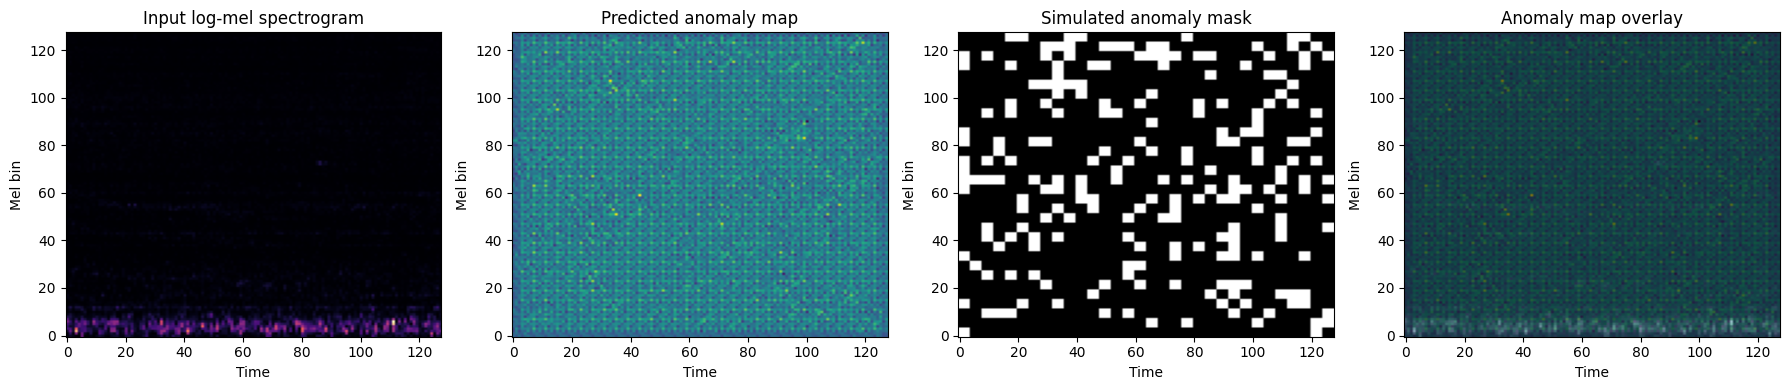

In [ ]:
import matplotlib.pyplot as plt

input_image = selected_input.squeeze().numpy()
anomaly_image = selected_anomaly_map.squeeze().numpy()
mask_image = F.interpolate(
    selected_latent_mask.float(),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="nearest",
).squeeze().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(input_image, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("Input log-mel spectrogram")

axes[1].imshow(anomaly_image, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("Predicted anomaly map")

axes[2].imshow(mask_image, origin="lower", aspect="auto", cmap="gray")
axes[2].set_title("Simulated anomaly mask")

axes[3].imshow(input_image, origin="lower", aspect="auto", cmap="gray")
axes[3].imshow(anomaly_image, origin="lower", aspect="auto", cmap="viridis", alpha=0.5)
axes[3].set_title("Anomaly map overlay")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.suptitle(f"Visualization file: {os.path.basename(selected_file)}", y=1.03)
plt.tight_layout()
plt.show()
